# 02_hypothetical_personas.ipynb

-----

In [86]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
plt.rcParams['text.usetex'] = True

In [ ]:
import yfinance as yf
import pandas as pd
import math

from src.data.utils import *

In [3]:
# Read the dictionary with the cleaned data
import pickle

with open("cleaned_data.pkl", "rb") as f:
    cleaned_data = pickle.load(f)

In [4]:
data_10y_1d = timeframe_selector(cleaned_data,
                   stocks=["AAPL", "MSFT", "IBM", "XOM", "WTM", "KO", "JNJ", "VZ", "KHC", "USB"],
                   timeframe='10y', freq='1d')

data_close_10y_1d = close_prices_df_generator(data_10y_1d)
returns_close_10y_1d = compute_returns(data_close_10y_1d)

## Import risk free rate

In [33]:
risk_free_rate = pd.read_csv('../data/processed/risk_free.csv',
                             index_col='observation_date',
                             parse_dates=True)

In [34]:
# Compute the daily risk free rate
daily_rf_rate = (1 + risk_free_rate)**(1 / 252) - 1
daily_rf_rate.columns = ['risk_free']

## Timeframe of analysis for Buy and Hold and Hedge Fund personas

In [13]:
# Timeframe window
start_date = '2015-10-15'
end_date = '2025-10-01'

# Isolate returns for this period
stock_returns = returns_close_10y_1d.loc['2015-10-15':'2025-10-01']

## 1. Buy and Hold

We have some options when having a buy-and-hold portfolio of stocks that pay dividends, some of the decisions we can made are:

1. Re-invest the dividends,
2. Cash-out the dividends,
3. Cash-out the dividends and store them on a savings account. 

We are going to analyze what's the terminal wealth of the buy and hold investor in the first scenario, which is the most common to occur in a buy-and-hold strategy.

### 1.1. Equally weighted portfolio

In [90]:
# Extract number of assets in the data
n_assets = stock_returns.shape[1]

# Generate n_assets equal weights
weights = np.full(n_assets, 1/n_assets)

# Define the timeframe
timeframe = (start_date, end_date)

# Compute equally weighted portfolio returns
portfolio_equally_ret = performance_metrics(weights, returns_close_10y_1d, daily_rf_rate, timeframe)

Now we can visualize the growth of our portfolio over this holding time, let's define our starting wealth (investment) to be

$$W_0 = \$1000000$$

In [144]:
drawdown_eq = portfolio_equally_ret[0]['drawdown']
sharpe_ratio_eq = portfolio_equally_ret[0]['annualized_sharpe']
total_return_eq = portfolio_equally_ret[0]['total_return'].item() * 100
max_drawdown_eq = portfolio_equally_ret[0]['max_drawdown'].item() * 100

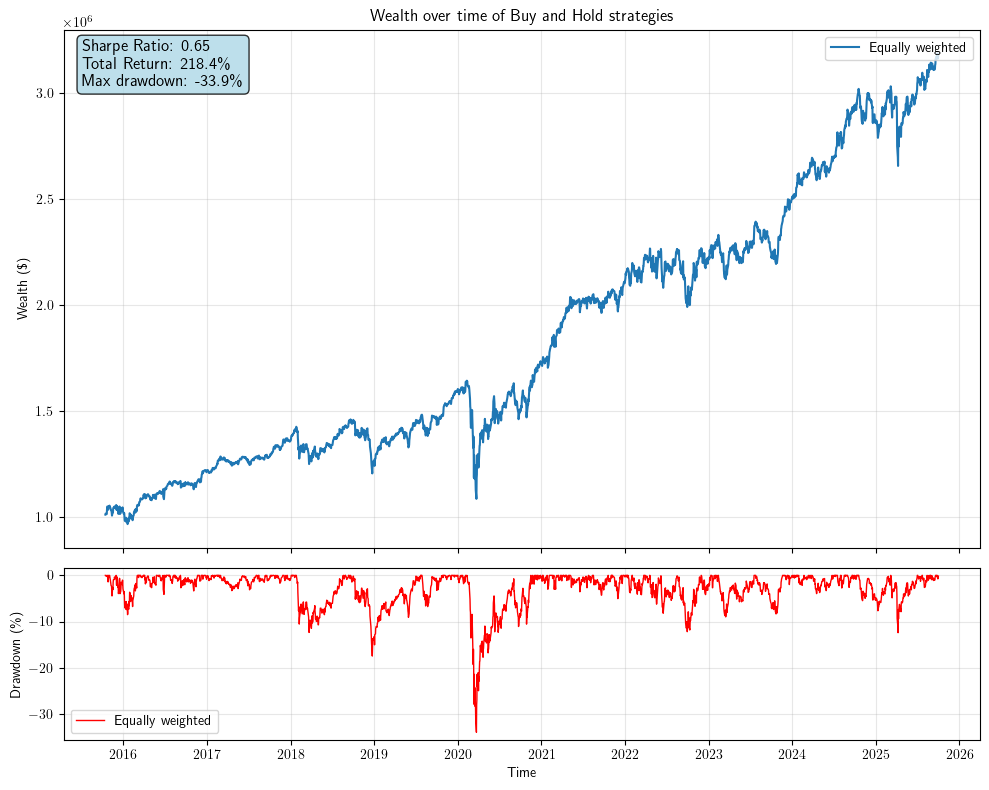

In [ ]:
# Visualize growth
W0 = 1e6
wealth_series_equally = W0 * portfolio_equally_ret[0]['wealth']

# Create subplots
fig, (ax1, ax2) = plt.subplots(
            2, 1, 
            figsize=(10, 8), 
            sharex=True, 
            gridspec_kw={'height_ratios': [3, 1]} # Make the top plot taller
        )

# Top plot: Wealth
ax1.plot(wealth_series_equally , label='Equally weighted')
ax1.set_ylabel(r'Wealth (\$)')
ax1.set_title('Wealth over time of Buy and Hold strategies')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Add metrics annotation to wealth plot
textstr = f'Sharpe Ratio: {sharpe_ratio_eq:.2f}\nTotal Return: {total_return_eq:.1f}\\%\nMax drawdown: {max_drawdown_eq:.1f}\\%'
props = dict(boxstyle='round', facecolor='lightblue', alpha=0.8)
ax1.text(0.02, 0.98, textstr, transform=ax1.transAxes, fontsize=12,
         verticalalignment='top', bbox=props)

# Bottom plot: Drawdown
ax2.plot(drawdown_eq * 100, color='red', linewidth=1, label='Equally weighted')
ax2.set_ylabel('Drawdown (\\%)')
ax2.set_xlabel('Time')
ax2.legend(loc='lower left')
ax2.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

### 1.2. Market Cap weighted portfolio

In [147]:
ticker_symbols = data_close_10y_1d.columns

# Get market capitalization data
mktcap_data = {}
for t in ticker_symbols:
    ticker = yf.Ticker(t)
    market_cap = ticker.fast_info['market_cap']
    mktcap_data[t] = market_cap

In [ ]:
# Total market capitalization
total_mktcap = sum(mktcap_data.values())

weights_mktcap = {key: value / total_mktcap for key, value in mktcap_data.items()}
ordered_weights = [weights_mktcap[f'{ticker}'] for ticker in returns_close_10y_1d.columns]

In [156]:
# Compute market cap weighted portfolio returns
portfolio_mktcap_ret = performance_metrics(ordered_weights, returns_close_10y_1d, daily_rf_rate, timeframe)

In [158]:
drawdown_mktcap = portfolio_mktcap_ret[0]['drawdown']
sharpe_ratio_mktcap = portfolio_mktcap_ret[0]['annualized_sharpe']
total_return_mktcap = portfolio_mktcap_ret[0]['total_return'].item() * 100
max_drawdown_mktcap = portfolio_mktcap_ret[0]['max_drawdown'].item() * 100

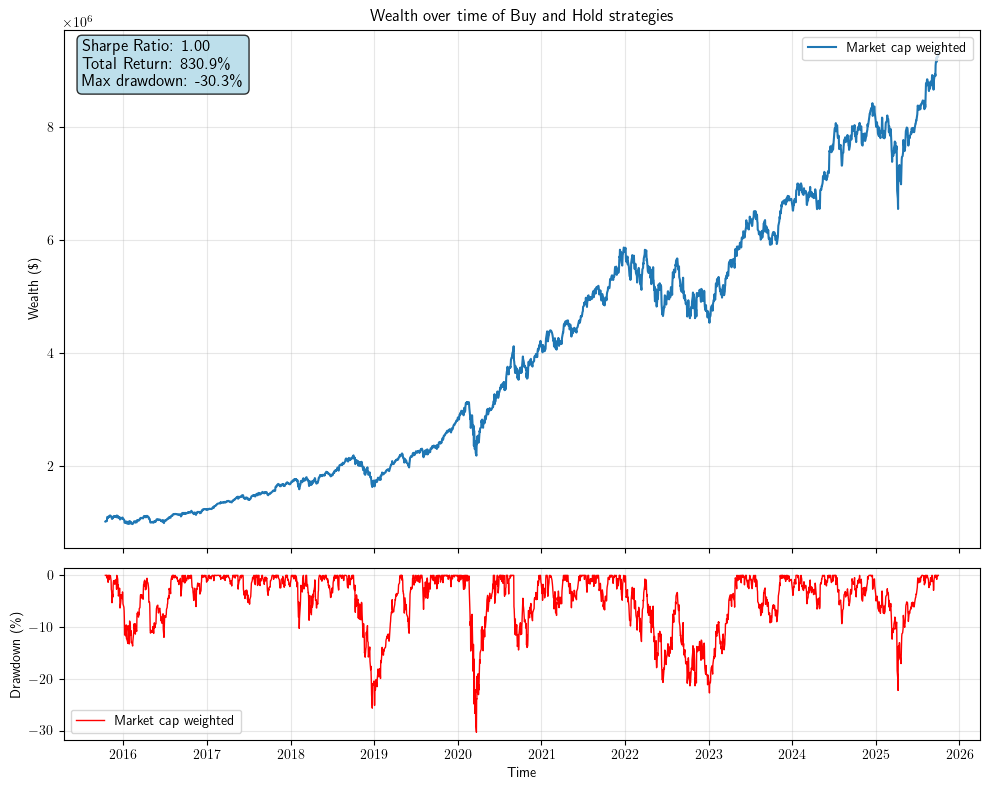

In [159]:
# Visualize growth
W0 = 1e6
wealth_series_mktcap = W0 * portfolio_mktcap_ret[0]['wealth']

# Create subplots
fig, (ax1, ax2) = plt.subplots(
            2, 1, 
            figsize=(10, 8), 
            sharex=True, 
            gridspec_kw={'height_ratios': [3, 1]} # Make the top plot taller
        )

# Top plot: Wealth
ax1.plot(wealth_series_mktcap , label='Market cap weighted')
ax1.set_ylabel(r'Wealth (\$)')
ax1.set_title('Wealth over time of Buy and Hold strategies')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Add metrics annotation to wealth plot
textstr = f'Sharpe Ratio: {sharpe_ratio_mktcap:.2f}\nTotal Return: {total_return_mktcap:.1f}\\%\nMax drawdown: {max_drawdown_mktcap:.1f}\\%'
props = dict(boxstyle='round', facecolor='lightblue', alpha=0.8)
ax1.text(0.02, 0.98, textstr, transform=ax1.transAxes, fontsize=12,
         verticalalignment='top', bbox=props)

# Bottom plot: Drawdown
ax2.plot(drawdown_mktcap * 100, color='red', linewidth=1, label='Market cap weighted')
ax2.set_ylabel('Drawdown (\\%)')
ax2.set_xlabel('Time')
ax2.legend(loc='lower left')
ax2.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

### 1.3. Logarithmic Market Cap weighted portfolio

Given that the previous weights for the market cap weighted portfolio are concentrating a lot of the weight in only 2 or 3 stocks, rendering the diversification of the other 8 stocks useless.

To solve this while still keeping a "size-based" logic (meaning bigger companies still get more weight, just not massively more), the standard solution is to implement a Logarithmic Market Cap Weighting.

Instead of weighting by the Market Cap ($M_i$) directly, we weight by the natural logarithm of the Market Cap ($\ln(M_i)$). This compresses the scale: Logarithms drastically shrink the difference between huge numbers. For example, a $3 Trillion company ($3 \times 10^{12}$) has a log value of $\approx 28.7$. A $100 Billion company ($1 \times 10^{11}$) has a log value of $\approx 25.3$.

Result: The $3T company is 30x bigger in real dollars, but only ~1.13x bigger in "log-weight" terms. This preserves the hierarchy (bigger is still heavier) but ensures the smaller stocks get a meaningful allocation.

In [196]:
# Transform market cap data into log market cap and compute the weights
log_mktcap_data = {}

for ticker in mktcap_data.keys():
    log_mktcap_data[f'{ticker}'] = math.log(mktcap_data[ticker])
    
# Total log market capitalization
total_log_mktcap = sum(log_mktcap_data.values())

weights_log_mktcap = {key: value / total_log_mktcap for key, value in log_mktcap_data.items()}
ordered_log_weights = [weights_log_mktcap[f'{ticker}'] for ticker in returns_close_10y_1d.columns]

In [199]:
# Compute log market cap weighted portfolio returns
portfolio_log_mktcap_ret = performance_metrics(ordered_log_weights, returns_close_10y_1d, daily_rf_rate, timeframe)

In [200]:
drawdown_log_mktcap = portfolio_log_mktcap_ret[0]['drawdown']
sharpe_ratio_log_mktcap = portfolio_log_mktcap_ret[0]['annualized_sharpe']
total_return_log_mktcap = portfolio_log_mktcap_ret[0]['total_return'].item() * 100
max_drawdown_log_mktcap = portfolio_log_mktcap_ret[0]['max_drawdown'].item() * 100

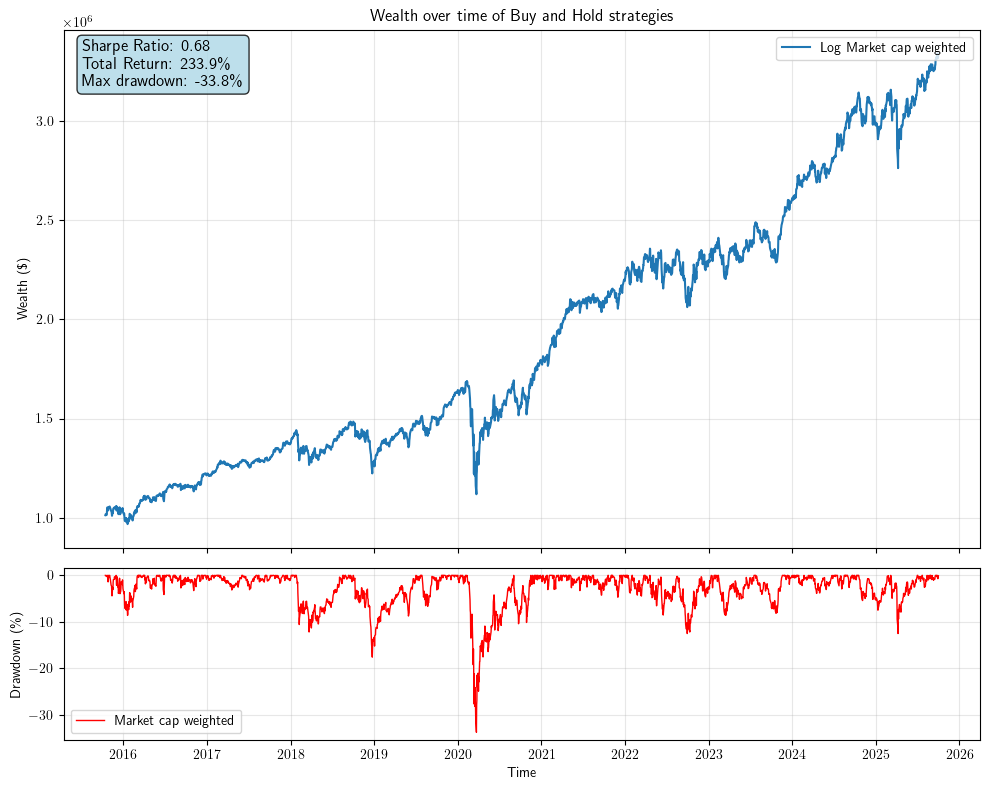

In [201]:
# Visualize growth
W0 = 1e6
wealth_series_log_mktcap = W0 * portfolio_log_mktcap_ret[0]['wealth']

# Create subplots
fig, (ax1, ax2) = plt.subplots(
            2, 1, 
            figsize=(10, 8), 
            sharex=True, 
            gridspec_kw={'height_ratios': [3, 1]} # Make the top plot taller
        )

# Top plot: Wealth
ax1.plot(wealth_series_log_mktcap , label='Log Market cap weighted')
ax1.set_ylabel(r'Wealth (\$)')
ax1.set_title('Wealth over time of Buy and Hold strategies')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Add metrics annotation to wealth plot
textstr = f'Sharpe Ratio: {sharpe_ratio_log_mktcap:.2f}\nTotal Return: {total_return_log_mktcap:.1f}\\%\nMax drawdown: {max_drawdown_log_mktcap:.1f}\\%'
props = dict(boxstyle='round', facecolor='lightblue', alpha=0.8)
ax1.text(0.02, 0.98, textstr, transform=ax1.transAxes, fontsize=12,
         verticalalignment='top', bbox=props)

# Bottom plot: Drawdown
ax2.plot(drawdown_log_mktcap * 100, color='red', linewidth=1, label='Market cap weighted')
ax2.set_ylabel('Drawdown (\\%)')
ax2.set_xlabel('Time')
ax2.legend(loc='lower left')
ax2.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

### Comparison of both strategies

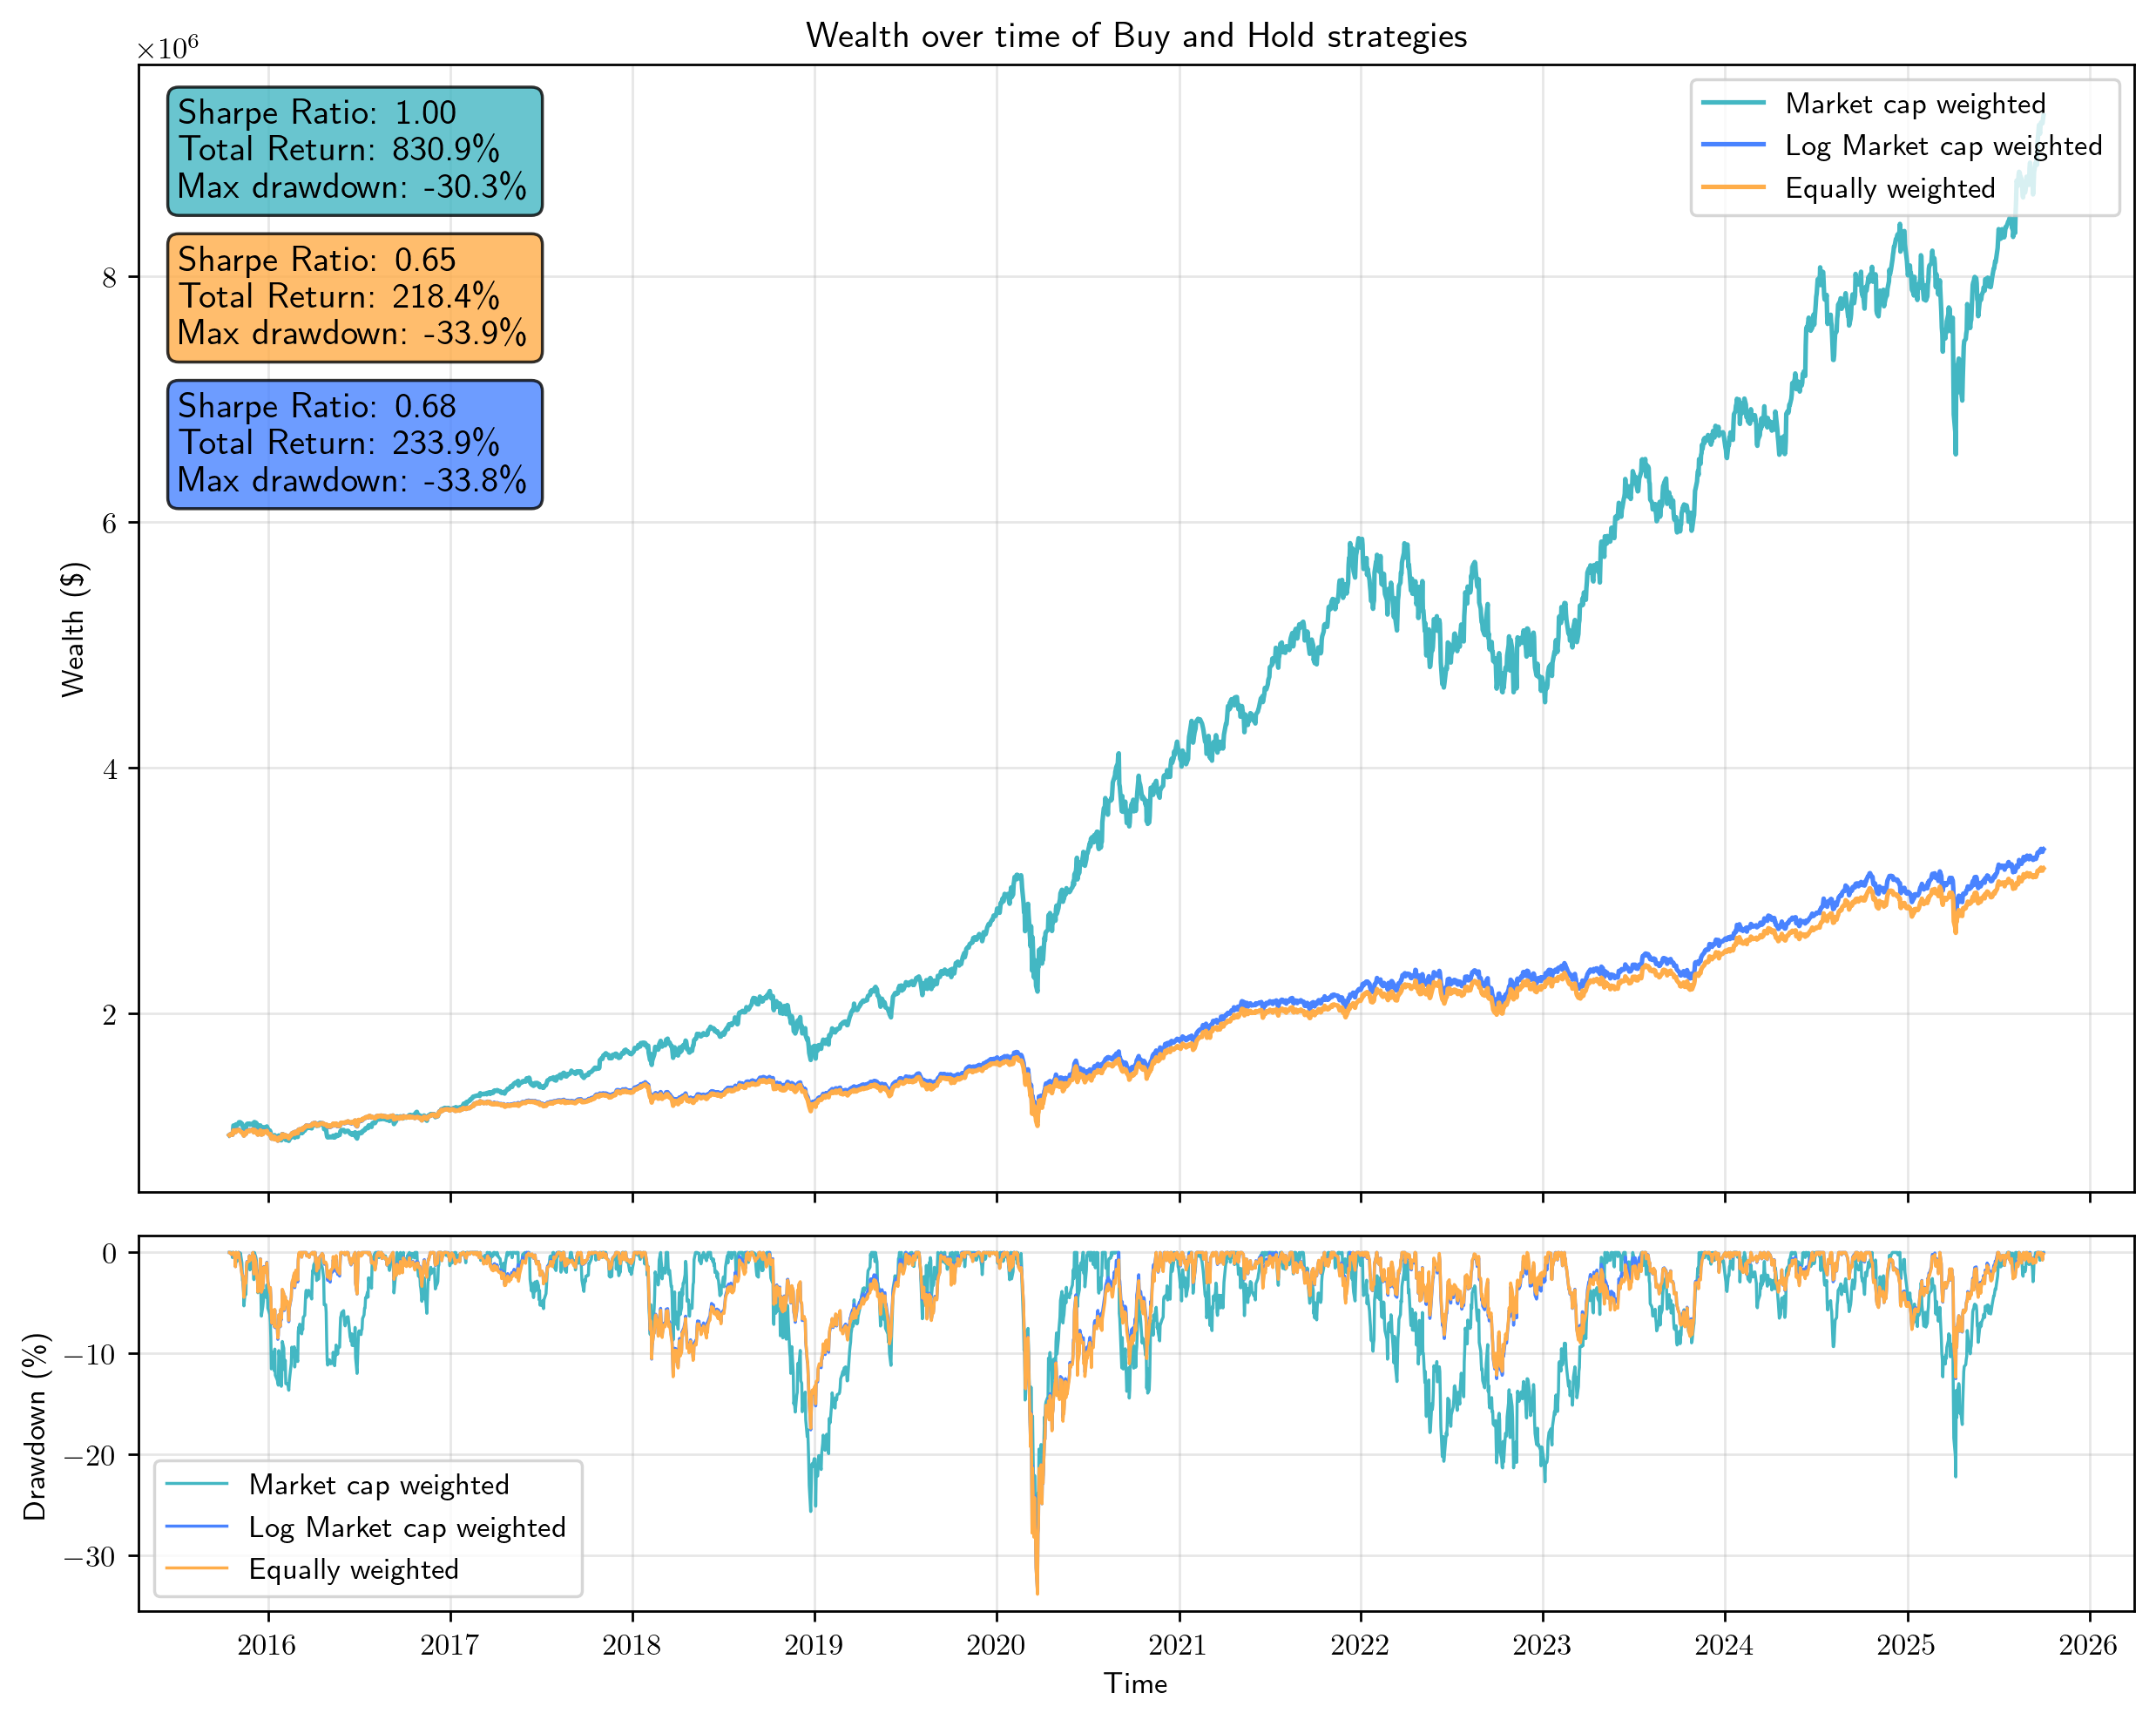

In [205]:
# Create subplots
fig, (ax1, ax2) = plt.subplots(
            2, 1, 
            figsize=(10, 8),
            dpi = 250,
            sharex=True, 
            gridspec_kw={'height_ratios': [3, 1]} # Make the top plot taller
        )

# Top plot: Wealth
ax1.plot(wealth_series_mktcap, color="#43b7c3", label='Market cap weighted')
ax1.plot(wealth_series_log_mktcap, color="#4983ff", label='Log Market cap weighted')
ax1.plot(wealth_series_equally, color="#ffad49", label='Equally weighted')
ax1.set_ylabel(r'Wealth (\$)')
ax1.set_title('Wealth over time of Buy and Hold strategies')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Add metrics annotation to wealth plot
textstr = f'Sharpe Ratio: {sharpe_ratio_mktcap:.2f}\nTotal Return: {total_return_mktcap:.1f}\\%\nMax drawdown: {max_drawdown_mktcap:.1f}\\%'
props = dict(boxstyle='round', facecolor="#43b7c3", alpha=0.8)
ax1.text(0.02, 0.97, textstr, transform=ax1.transAxes, fontsize=12,
         verticalalignment='top', bbox=props)

# Add metrics annotation to wealth plot
textstr2 = f'Sharpe Ratio: {sharpe_ratio_eq:.2f}\nTotal Return: {total_return_eq:.1f}\\%\nMax drawdown: {max_drawdown_eq:.1f}\\%'
props = dict(boxstyle='round', facecolor='#ffad49', alpha=0.8)
ax1.text(0.02, 0.84, textstr2, transform=ax1.transAxes, fontsize=12,
         verticalalignment='top', bbox=props)

# Add metrics annotation to wealth plot
textstr3 = f'Sharpe Ratio: {sharpe_ratio_log_mktcap:.2f}\nTotal Return: {total_return_log_mktcap:.1f}\\%\nMax drawdown: {max_drawdown_log_mktcap:.1f}\\%'
props = dict(boxstyle='round', facecolor="#4983ff", alpha=0.8)
ax1.text(0.02, 0.71, textstr3, transform=ax1.transAxes, fontsize=12,
         verticalalignment='top', bbox=props)


# Bottom plot: Drawdown
ax2.plot(drawdown_mktcap * 100, color="#43b7c3", linewidth=1, label='Market cap weighted')
ax2.plot(drawdown_log_mktcap * 100, color="#4983ff", linewidth=1, label='Log Market cap weighted')
ax2.plot(drawdown_eq * 100, color="#ffad49", linewidth=1, label='Equally weighted')
ax2.set_ylabel('Drawdown (\\%)')
ax2.set_xlabel('Time')
ax2.legend(loc='lower left')
ax2.grid(True, alpha=0.3)


plt.tight_layout()
plt.savefig('../data/images/comparison_buy_and_hold.png')
plt.show()

We have some options when having a buy-and-hold portfolio of stocks that pay dividends, some of the decisions we can made are:

1. Re-invest the dividends,
2. Cash-out the dividends,
3. Cash-out the dividends and store them on a savings account. 

We are going to analyze what's the terminal wealth of the buy and hold investor in these 3 scenarios.

Now we are going to do the same analysis but in presence of dividens, this is, we are going to invest the proportional amount received from the dividend into the portfolio.

### 1.3. Geometric weighted portfolio

In [216]:
def get_geometric_weights(tickers, r=1.2):
    """
    Generates weights based on a geometric progression parameter 'r' (Step B in paper).
    
    The paper mentions "Step thru values of r". 
    If r=1, weights are equal.
    If r>1, weights are concentrated in the top ranks.
    
    Formula used: w_i = r^(N-i) / Sum(r^(N-j))
    This assigns higher weights to the first items in the list.
    """
    n = len(tickers)
    # Generate ranks [N-1, N-2, ... 0]
    ranks = np.arange(n)[::-1] 
    
    # Calculate raw geometric weights
    raw_weights = np.power(r, ranks)
    
    # Normalize to sum to 1
    normalized_weights = raw_weights / raw_weights.sum()
    
    # Assign to tickers (assuming tickers are passed in desired rank order)
    # Note: For the permutation analysis, the initial order doesn't matter,
    # as we test ALL orders.
    # weights = pd.Series(normalized_weights, index=tickers)
    return normalized_weights

In [217]:
geometric_weights = get_geometric_weights(ticker_symbols)

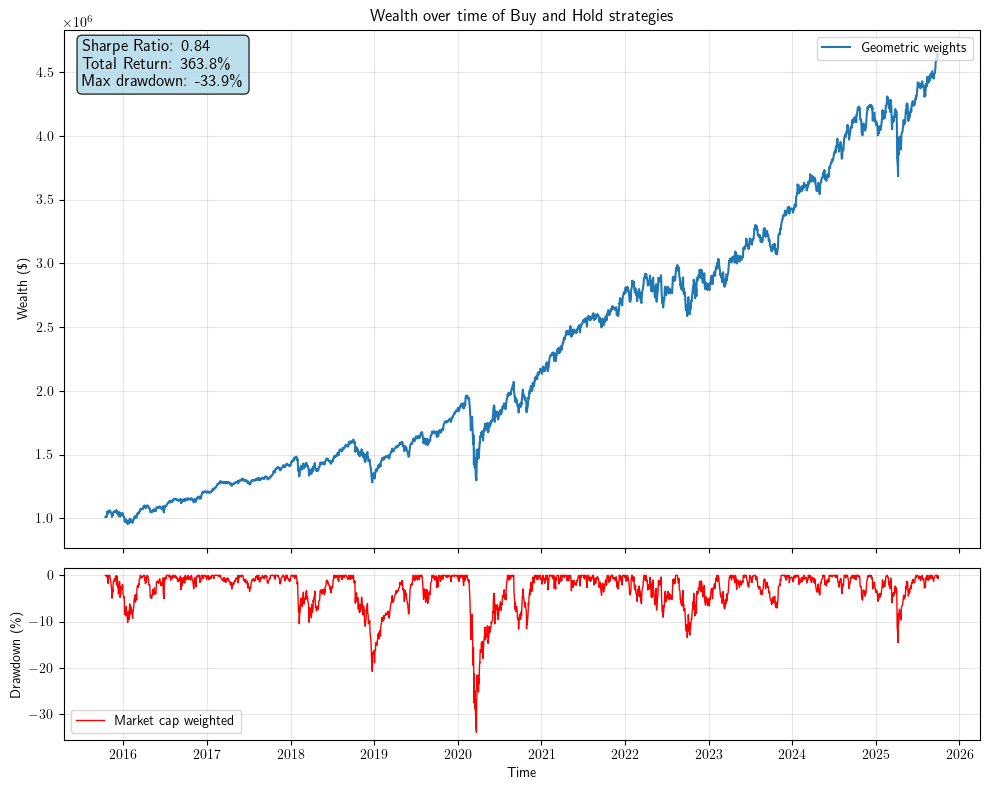

In [220]:
# Compute log market cap weighted portfolio returns
portfolio_geo_weights_ret = performance_metrics(geometric_weights, returns_close_10y_1d, daily_rf_rate, timeframe)
drawdown_geo_weights = portfolio_geo_weights_ret[0]['drawdown']
sharpe_ratio_geo_weights = portfolio_geo_weights_ret[0]['annualized_sharpe']
total_return_geo_weights = portfolio_geo_weights_ret[0]['total_return'].item() * 100
max_drawdown_geo_weights = portfolio_geo_weights_ret[0]['max_drawdown'].item() * 100
# Visualize growth
W0 = 1e6
wealth_series_geo_weights = W0 * portfolio_geo_weights_ret[0]['wealth']

# Create subplots
fig, (ax1, ax2) = plt.subplots(
            2, 1, 
            figsize=(10, 8), 
            sharex=True, 
            gridspec_kw={'height_ratios': [3, 1]} # Make the top plot taller
        )

# Top plot: Wealth
ax1.plot(wealth_series_geo_weights , label='Geometric weights')
ax1.set_ylabel(r'Wealth (\$)')
ax1.set_title('Wealth over time of Buy and Hold strategies')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Add metrics annotation to wealth plot
textstr = f'Sharpe Ratio: {sharpe_ratio_geo_weights:.2f}\nTotal Return: {total_return_geo_weights:.1f}\\%\nMax drawdown: {max_drawdown_geo_weights:.1f}\\%'
props = dict(boxstyle='round', facecolor='lightblue', alpha=0.8)
ax1.text(0.02, 0.98, textstr, transform=ax1.transAxes, fontsize=12,
         verticalalignment='top', bbox=props)

# Bottom plot: Drawdown
ax2.plot(drawdown_geo_weights * 100, color='red', linewidth=1, label='Market cap weighted')
ax2.set_ylabel('Drawdown (\\%)')
ax2.set_xlabel('Time')
ax2.legend(loc='lower left')
ax2.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()